# PhonePe Pulse — Transaction Data Analysis

## Table of Contents
1. [Data Loading and Preparation](#1.-Data-Loading-and-Preparation)
2. [Overall Transaction Growth](#2.-Overall-Transaction-Growth)
   - [Quarterly Transaction Volume & Value Trends](#Quarterly-Transaction-Volume-&-Value-Trends)
3. [Transaction Type Analysis](#3.-Transaction-Type-Analysis)
   - [Volume vs. Value Share by Transaction Type](#Volume-vs.-Value-Share-by-Transaction-Type)
   - [Type-level Quarterly and Yearly Trends](#Type-level-Quarterly-and-Yearly-Trends)
4. [State-Level Transaction Analysis](#4.-State-Level-Transaction-Analysis)
   - [Top States by Volume and Value](#Top-States-by-Volume-and-Value)
   - [State-Level Growth Analysis](#State-Level-Growth-Analysis)
   - [Average Transaction Value by State](#Average-Transaction-Value-by-State)
5. [Key Findings](#5.-Key-Findings)


## 1. Data Loading and Preparation

In [1]:
import json
import pandas as pd
import os
import matplotlib.pyplot as plt

# Base path for India country-level aggregated transaction data
base_path = "../pulse-main/data/aggregated/transaction/country/india"

all_rows = []

for year in sorted(os.listdir(base_path)):
    year_path = os.path.join(base_path, year)
    
    # Make sure it is a folder
    if not os.path.isdir(year_path):
        continue
    
    for quarter in sorted(os.listdir(year_path)):
        file_path = os.path.join(year_path, quarter)
        
        # Make sure it is a JSON file
        if not quarter.endswith(".json"):
            continue
        
        with open(file_path, "r") as f:
            data = json.load(f)
        
        transaction_data = data["data"]["transactionData"]
        
        for transaction in transaction_data:
            name = transaction["name"]
            instrument = transaction["paymentInstruments"][0]
            
            all_rows.append({
                "transaction_type": name,
                "transaction_count": instrument["count"],
                "transaction_amount": instrument["amount"],
                "year": int(year),
                "quarter": int(quarter.replace(".json", ""))
            })

In [2]:
# Create main DataFrame
df = pd.DataFrame(all_rows)
df.head()

,transaction_type,transaction_count,transaction_amount,year,quarter
0,Retail,89921478,2.056876e+10,2018,1
1,Utility,2955878,4.708627e+09,2018,1
2,P2P,47101116,1.472459e+11,2018,1
3,P2P,74704527,2.647677e+11,2018,2
4,Retail,111138041,3.022087e+10,2018,2


In [3]:
# Inspect shape and records per quarter
print("Dataframe shape:", df.shape)
df.groupby(["year", "quarter"]).size().head(10)

Dataframe shape: (102, 5)


year  quarter
2018  1          3
      2          3
      3          3
      4          3
2019  1          3
      2          3
      3          3
      4          3
2020  1          3
      2          3
dtype: int64

In [4]:
# Calculate average transaction value per record
df["avg_transaction_value"] = (
    df["transaction_amount"] / df["transaction_count"]
)
df.head()

,transaction_type,transaction_count,transaction_amount,year,quarter,avg_transaction_value
0,Retail,89921478,2.056876e+10,2018,1,228.741347
1,Utility,2955878,4.708627e+09,2018,1,1592.970775
2,P2P,47101116,1.472459e+11,2018,1,3126.165493
3,P2P,74704527,2.647677e+11,2018,2,3544.198481
4,Retail,111138041,3.022087e+10,2018,2,271.921962


In [5]:
# Aggregate quarterly summary
quarterly_summary = (
    df.groupby(["year", "quarter"])
      .agg(
          total_transactions=("transaction_count", "sum"),
          total_transaction_amount=("transaction_amount", "sum")
      )
      .reset_index()
)

quarterly_summary.head()

,year,quarter,total_transactions,total_transaction_amount
0,2018,1,139978472,1.725233e+11
1,2018,2,193648476,3.052798e+11
2,2018,3,347025910,4.760333e+11
3,2018,4,428390875,6.732832e+11
4,2019,1,720286340,9.922936e+11


In [6]:
# Format period label and scaled metrics (Millions / Trillions)
quarterly_summary["period"] = (
    quarterly_summary["year"].astype(str)
    + " Q"
    + quarterly_summary["quarter"].astype(str)
)

quarterly_summary["transactions_mn"] = (
    quarterly_summary["total_transactions"] / 1e6
)

quarterly_summary["amount_trillion"] = (
    quarterly_summary["total_transaction_amount"] / 1e12
)

quarterly_summary.head()

,year,quarter,total_transactions,total_transaction_amount,period,transactions_mn,amount_trillion
0,2018,1,139978472,1.725233e+11,2018 Q1,139.978472,0.172523
1,2018,2,193648476,3.052798e+11,2018 Q2,193.648476,0.305280
2,2018,3,347025910,4.760333e+11,2018 Q3,347.025910,0.476033
3,2018,4,428390875,6.732832e+11,2018 Q4,428.390875,0.673283
4,2019,1,720286340,9.922936e+11,2019 Q1,720.286340,0.992294


## 2. Overall Transaction Growth

### Quarterly Transaction Volume & Value Trends

In [7]:
# Calculate Quarter-over-Quarter (QoQ) percentage growth
quarterly_summary["transaction_growth_pct"] = (
    quarterly_summary["total_transactions"]
    .pct_change() * 100
)

quarterly_summary["amount_growth_pct"] = (
    quarterly_summary["total_transaction_amount"]
    .pct_change() * 100
)

quarterly_summary.head(10)

,year,quarter,total_transactions,total_transaction_amount,period,transactions_mn,amount_trillion,transaction_growth_pct,amount_growth_pct
0,2018,1,139978472,1.725233e+11,2018 Q1,139.978472,0.172523,NaN,NaN
1,2018,2,193648476,3.052798e+11,2018 Q2,193.648476,0.305280,38.341613,76.949925
2,2018,3,347025910,4.760333e+11,2018 Q3,347.025910,0.476033,79.204049,55.933459
3,2018,4,428390875,6.732832e+11,2018 Q4,428.390875,0.673283,23.446366,41.436151
4,2019,1,720286340,9.922936e+11,2019 Q1,720.286340,0.992294,68.137648,47.381305
5,2019,2,827651243,1.356993e+12,2019 Q2,827.651243,1.356993,14.905864,36.753206
6,2019,3,1105941812,1.675693e+12,2019 Q3,1105.941812,1.675693,33.624135,23.485706
7,2019,4,1470544201,2.263090e+12,2019 Q4,1470.544201,2.263090,32.967592,35.053988
8,2020,1,1632700391,2.700008e+12,2020 Q1,1632.700391,2.700008,11.026951,19.306259
9,2020,2,1460073590,2.648633e+12,2020 Q2,1460.073590,2.648633,-10.573085,-1.902790


In [8]:
# Highest QoQ transaction volume growth
quarterly_summary.loc[
    quarterly_summary["transaction_growth_pct"].idxmax()
]

year                                       2018
quarter                                       3
total_transactions                    347025910
total_transaction_amount    476033348896.021362
period                                  2018 Q3
transactions_mn                       347.02591
amount_trillion                        0.476033
transaction_growth_pct                79.204049
amount_growth_pct                     55.933459
Name: 2, dtype: object

In [9]:
# Lowest QoQ transaction volume growth
quarterly_summary.loc[
    quarterly_summary["transaction_growth_pct"].idxmin()
]

year                                        2020
quarter                                        2
total_transactions                    1460073590
total_transaction_amount    2648632512844.319336
period                                   2020 Q2
transactions_mn                       1460.07359
amount_trillion                         2.648633
transaction_growth_pct                -10.573085
amount_growth_pct                       -1.90279
Name: 9, dtype: object

In [10]:
# Highest QoQ transaction amount growth
quarterly_summary.loc[
    quarterly_summary["amount_growth_pct"].idxmax()
]

year                                       2018
quarter                                       2
total_transactions                    193648476
total_transaction_amount    305279798417.882202
period                                  2018 Q2
transactions_mn                      193.648476
amount_trillion                         0.30528
transaction_growth_pct                38.341613
amount_growth_pct                     76.949925
Name: 1, dtype: object

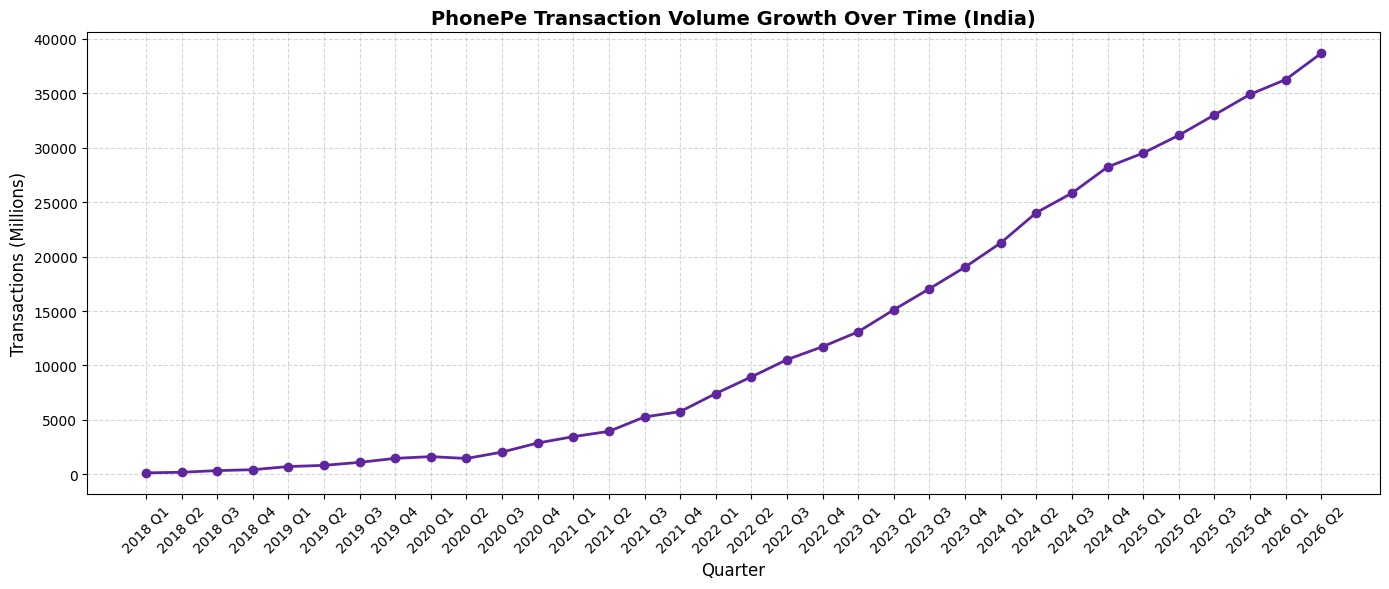

In [11]:
# Visualizing Transaction Volume Growth Over Time
plt.figure(figsize=(14, 6))

plt.plot(
    quarterly_summary["period"],
    quarterly_summary["transactions_mn"],
    marker="o",
    color="#5f259f",
    linewidth=2
)

plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Transactions (Millions)", fontsize=12)
plt.title("PhonePe Transaction Volume Growth Over Time (India)", fontsize=14, fontweight="bold")

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

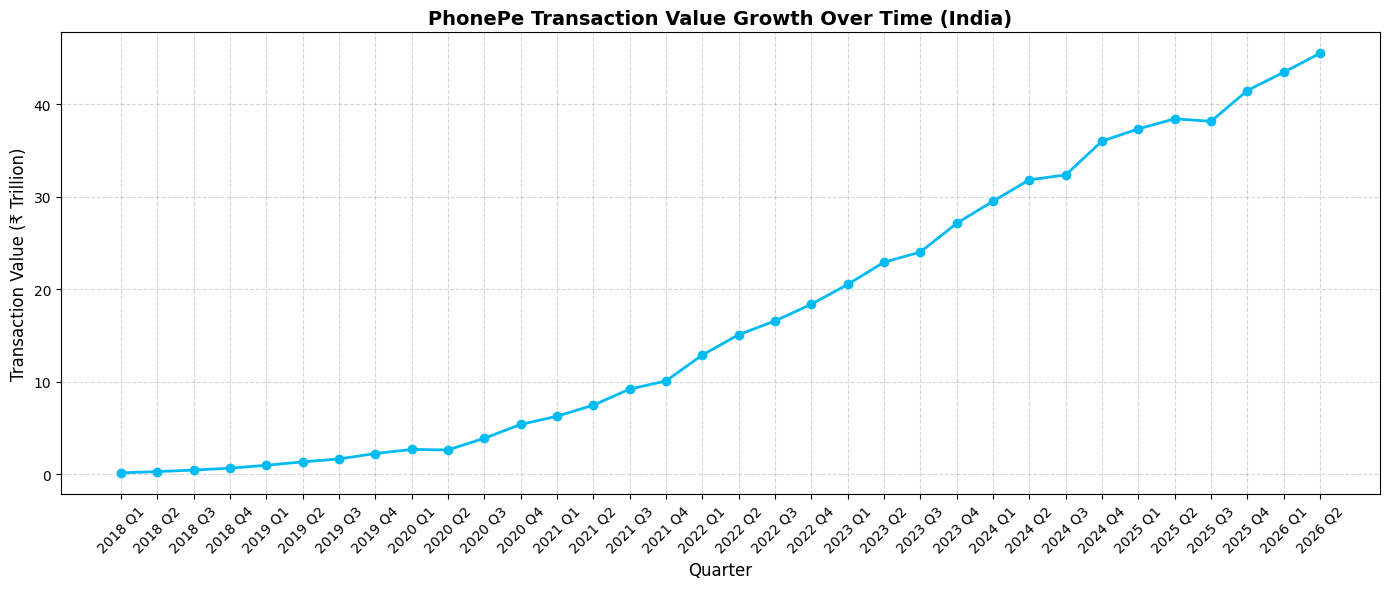

In [12]:
# Visualizing Transaction Value Growth Over Time
plt.figure(figsize=(14, 6))

plt.plot(
    quarterly_summary["period"],
    quarterly_summary["amount_trillion"],
    marker="o",
    color="#00baf2",
    linewidth=2
)

plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Transaction Value (₹ Trillion)", fontsize=12)
plt.title("PhonePe Transaction Value Growth Over Time (India)", fontsize=14, fontweight="bold")

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Transaction Type Analysis

### P2P, Retail, and Utility Transactions

In [13]:
# Summary by transaction type
transaction_type_summary = (
    df.groupby("transaction_type")
      .agg(
          total_transactions=("transaction_count", "sum"),
          total_transaction_amount=("transaction_amount", "sum")
      )
      .reset_index()
)

transaction_type_summary["transactions_bn"] = (
    transaction_type_summary["total_transactions"] / 1e9
)

transaction_type_summary["amount_trillion"] = (
    transaction_type_summary["total_transaction_amount"] / 1e12
)

transaction_type_summary["transaction_share_pct"] = (
    transaction_type_summary["total_transactions"]
    / transaction_type_summary["total_transactions"].sum() * 100
)

transaction_type_summary["amount_share_pct"] = (
    transaction_type_summary["total_transaction_amount"]
    / transaction_type_summary["total_transaction_amount"].sum() * 100
)

transaction_type_summary["avg_transaction_value"] = (
    transaction_type_summary["total_transaction_amount"]
    / transaction_type_summary["total_transactions"]
)

transaction_type_summary

,transaction_type,total_transactions,total_transaction_amount,transactions_bn,amount_trillion,transaction_share_pct,amount_share_pct,avg_transaction_value
0,P2P,148945088921,4.416027e+14,148.945089,441.602686,34.049272,75.197291,2964.869061
1,Retail,256879921733,1.168563e+14,256.879922,116.856272,58.723483,19.898600,454.906210
2,Utility,31614852053,2.879981e+13,31.614852,28.799810,7.227245,4.904109,910.958250


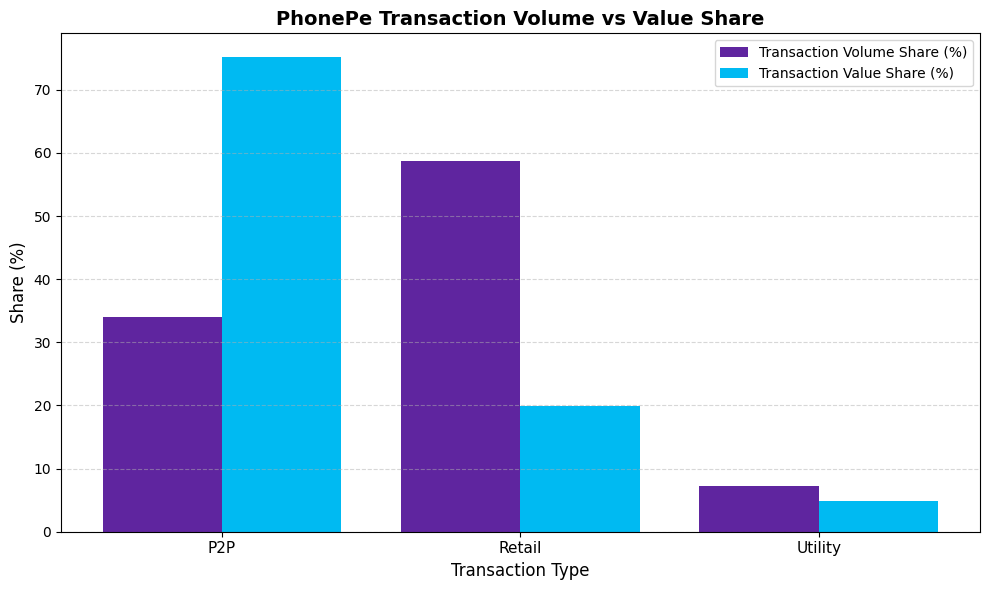

In [14]:
# Comparing Transaction Volume vs Value Share
x = range(len(transaction_type_summary))

plt.figure(figsize=(10, 6))

plt.bar(
    [i - 0.2 for i in x],
    transaction_type_summary["transaction_share_pct"],
    width=0.4,
    label="Transaction Volume Share (%)",
    color="#5f259f"
)

plt.bar(
    [i + 0.2 for i in x],
    transaction_type_summary["amount_share_pct"],
    width=0.4,
    label="Transaction Value Share (%)",
    color="#00baf2"
)

plt.xticks(
    x,
    transaction_type_summary["transaction_type"],
    fontsize=11
)

plt.xlabel("Transaction Type", fontsize=12)
plt.ylabel("Share (%)", fontsize=12)
plt.title("PhonePe Transaction Volume vs Value Share", fontsize=14, fontweight="bold")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
# Aggregate quarterly breakdown by transaction type
type_quarterly = (
    df.groupby(["year", "quarter", "transaction_type"])
      .agg(
          transactions=("transaction_count", "sum"),
          amount=("transaction_amount", "sum")
      )
      .reset_index()
)

type_quarterly["period"] = (
    type_quarterly["year"].astype(str)
    + " Q"
    + type_quarterly["quarter"].astype(str)
)

type_quarterly.head(10)

,year,quarter,transaction_type,transactions,amount,period
0,2018,1,P2P,47101116,1.472459e+11,2018 Q1
1,2018,1,Retail,89921478,2.056876e+10,2018 Q1
2,2018,1,Utility,2955878,4.708627e+09,2018 Q1
3,2018,2,P2P,74704527,2.647677e+11,2018 Q2
4,2018,2,Retail,111138041,3.022087e+10,2018 Q2
5,2018,2,Utility,7805908,1.029125e+10,2018 Q2
6,2018,3,P2P,202136497,4.259674e+11,2018 Q3
7,2018,3,Retail,133122344,3.513222e+10,2018 Q3
8,2018,3,Utility,11767069,1.493371e+10,2018 Q3
9,2018,4,P2P,200253637,5.949957e+11,2018 Q4


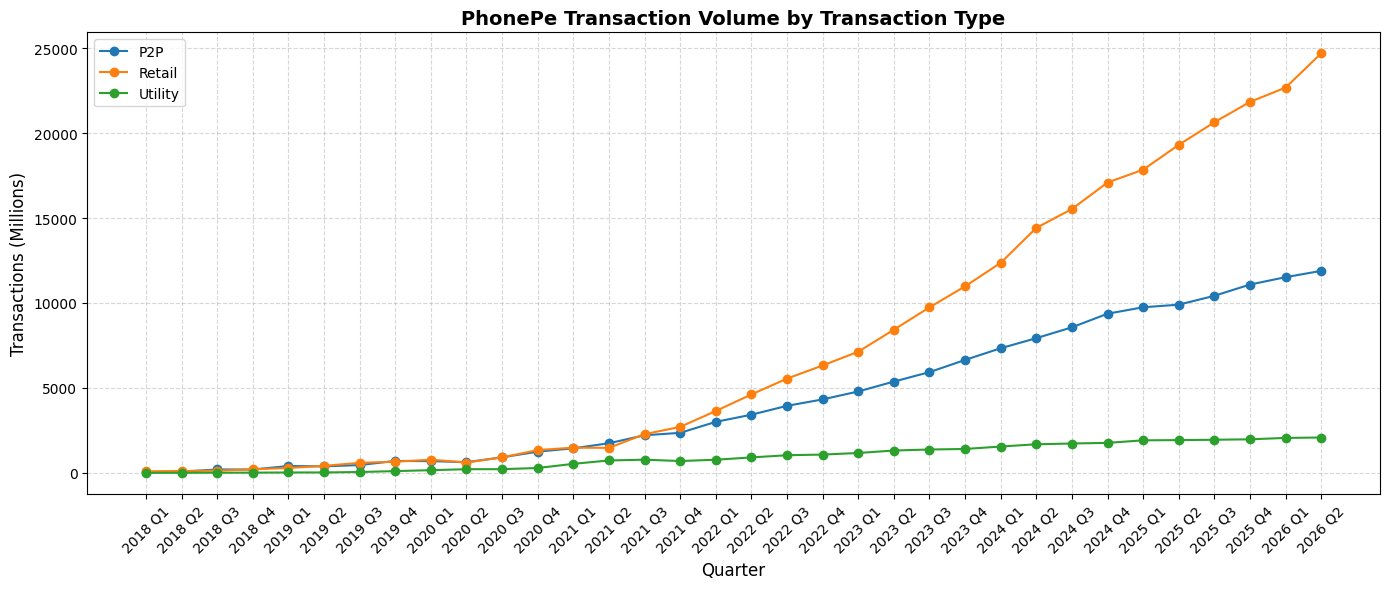

In [16]:
# Trend of Transaction Volume by Type
plt.figure(figsize=(14, 6))

for transaction_type in type_quarterly["transaction_type"].unique():
    temp = type_quarterly[
        type_quarterly["transaction_type"] == transaction_type
    ]
    plt.plot(
        temp["period"],
        temp["transactions"] / 1e6,
        marker="o",
        label=transaction_type
    )

plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Transactions (Millions)", fontsize=12)
plt.title("PhonePe Transaction Volume by Transaction Type", fontsize=14, fontweight="bold")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

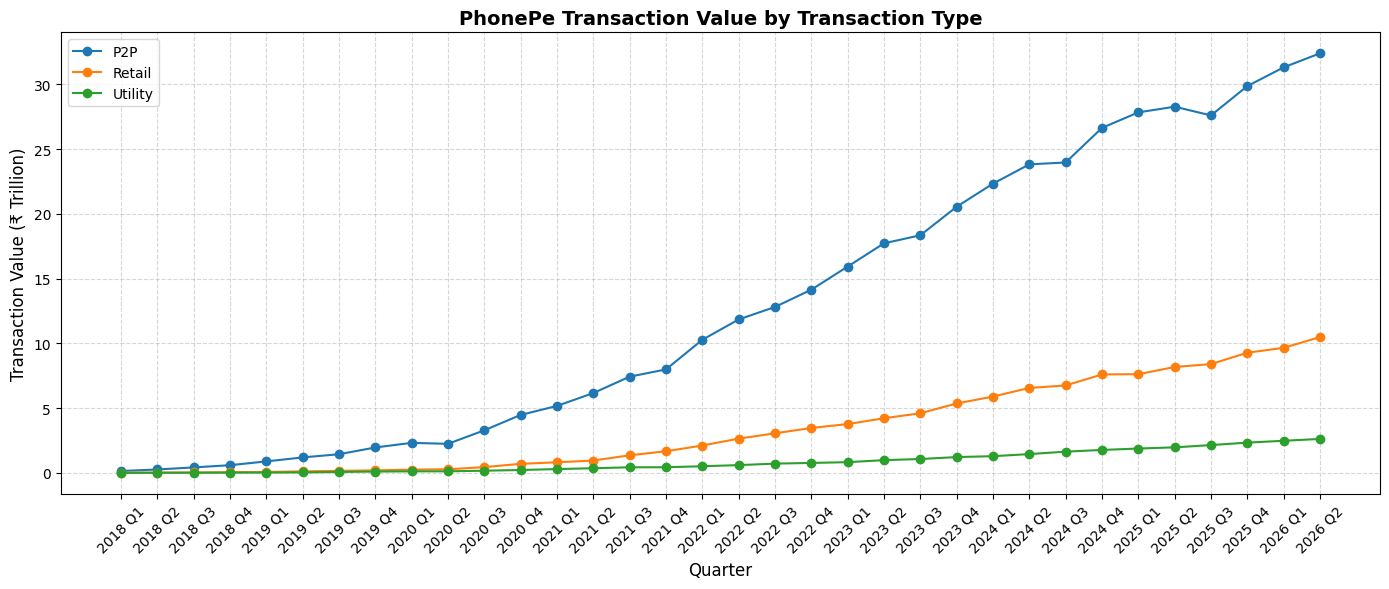

In [17]:
# Trend of Transaction Value by Type
plt.figure(figsize=(14, 6))

for transaction_type in type_quarterly["transaction_type"].unique():
    temp = type_quarterly[
        type_quarterly["transaction_type"] == transaction_type
    ]
    plt.plot(
        temp["period"],
        temp["amount"] / 1e12,
        marker="o",
        label=transaction_type
    )

plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Transaction Value (₹ Trillion)", fontsize=12)
plt.title("PhonePe Transaction Value by Transaction Type", fontsize=14, fontweight="bold")

plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
# Aggregate yearly metrics by transaction type
yearly_type = (
    df.groupby(["year", "transaction_type"])
      .agg(
          transactions=("transaction_count", "sum"),
          amount=("transaction_amount", "sum")
      )
      .reset_index()
)

yearly_type["transactions_bn"] = (
    yearly_type["transactions"] / 1e9
)

yearly_type["amount_trillion"] = (
    yearly_type["amount"] / 1e12
)

yearly_type = yearly_type.sort_values(
    ["transaction_type", "year"]
)

yearly_type["transaction_growth_pct"] = (
    yearly_type.groupby("transaction_type")["transactions"]
    .pct_change() * 100
)

yearly_type["amount_growth_pct"] = (
    yearly_type.groupby("transaction_type")["amount"]
    .pct_change() * 100
)

yearly_type.head(10)

,year,transaction_type,transactions,amount,transactions_bn,amount_trillion,transaction_growth_pct,amount_growth_pct
0,2018,P2P,524195777,1.432977e+12,0.524196,1.432977,NaN,NaN
3,2019,P2P,1955659685,5.488783e+12,1.955660,5.488783,273.078108,283.033687
6,2020,P2P,3492165927,1.232608e+13,3.492166,12.326078,78.567158,124.568489
9,2021,P2P,7765367854,2.675171e+13,7.765368,26.751711,122.365375,117.033438
12,2022,P2P,14701456015,4.907223e+13,14.701456,49.072232,89.320793,83.435865
15,2023,P2P,22744323623,7.253541e+13,22.744324,72.535414,54.707966,47.813561
18,2024,P2P,33201235118,9.674482e+13,33.201235,96.744818,45.975918,33.375979
21,2025,P2P,41152641116,1.135544e+14,41.152641,113.554402,23.949127,17.375177
24,2026,P2P,23408043806,6.369627e+13,23.408044,63.696271,-43.118976,-43.906824
1,2018,Retail,546429092,1.438828e+11,0.546429,0.143883,NaN,NaN


In [19]:
# Strongest volume growth year for each transaction type
growth_summary = (
    yearly_type.dropna(subset=["transaction_growth_pct"])
    .loc[
        yearly_type.groupby("transaction_type")["transaction_growth_pct"]
        .idxmax()
    ]
    [["transaction_type", "year", "transaction_growth_pct"]]
)

growth_summary

,transaction_type,year,transaction_growth_pct
3,P2P,2019,273.078108
4,Retail,2019,258.220325
5,Utility,2019,450.104345


In [20]:
# Strongest value growth year for each transaction type
amount_growth_summary = (
    yearly_type.dropna(subset=["amount_growth_pct"])
    .loc[
        yearly_type.groupby("transaction_type")["amount_growth_pct"]
        .idxmax()
    ]
    [["transaction_type", "year", "amount_growth_pct"]]
)

amount_growth_summary

,transaction_type,year,amount_growth_pct
3,P2P,2019,283.033687
4,Retail,2019,282.807989
5,Utility,2019,394.410328


## 4. State-Level Transaction Analysis

In [21]:
# Base path for state-level aggregated transactions
state_base_path = "../pulse-main/data/aggregated/transaction/country/india/state"

states = sorted(os.listdir(state_base_path))
print(f"Total states/UTs found: {len(states)}")
print("Sample states:", states[:10])

Total states/UTs found: 36
Sample states: ['andaman-&-nicobar-islands', 'andhra-pradesh', 'arunachal-pradesh', 'assam', 'bihar', 'chandigarh', 'chhattisgarh', 'dadra-&-nagar-haveli-&-daman-&-diu', 'delhi', 'goa']


In [22]:
# Load all state-level transaction data
all_state_rows = []

for state in sorted(os.listdir(state_base_path)):
    state_path = os.path.join(state_base_path, state)
    
    if not os.path.isdir(state_path):
        continue
    
    for year in sorted(os.listdir(state_path)):
        year_path = os.path.join(state_path, year)
        
        if not os.path.isdir(year_path):
            continue
        
        for quarter in sorted(os.listdir(year_path)):
            if not quarter.endswith(".json"):
                continue
            
            file_path = os.path.join(year_path, quarter)
            
            with open(file_path, "r") as f:
                data = json.load(f)
            
            transaction_data = data["data"]["transactionData"]
            
            for transaction in transaction_data:
                name = transaction["name"]
                instrument = transaction["paymentInstruments"][0]
                
                all_state_rows.append({
                    "state": state,
                    "year": int(year),
                    "quarter": int(quarter.replace(".json", "")),
                    "transaction_type": name,
                    "transaction_count": instrument["count"],
                    "transaction_amount": instrument["amount"]
                })

# Create DataFrame for state data
df_state = pd.DataFrame(all_state_rows)
df_state.head()

,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,P2P,2297,1.551346e+07
1,andaman-&-nicobar-islands,2018,1,Retail,6656,1.848410e+06
2,andaman-&-nicobar-islands,2018,1,Utility,136,1.207260e+06
3,andaman-&-nicobar-islands,2018,2,P2P,4383,3.074418e+07
4,andaman-&-nicobar-islands,2018,2,Retail,10462,3.511613e+06


In [23]:
# State dataframe dimensions and summary
print("State DataFrame Shape:", df_state.shape)
print("Unique states:", df_state["state"].nunique())
print("Years covered:", sorted(df_state["year"].unique()))
print("Quarters covered:", sorted(df_state["quarter"].unique()))

State DataFrame Shape: (3671, 6)
Unique states: 36
Years covered: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Quarters covered: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [24]:
# Aggregate state-level totals
state_summary = (
    df_state.groupby("state")
    .agg(
        total_transactions=("transaction_count", "sum"),
        total_transaction_amount=("transaction_amount", "sum")
    )
    .reset_index()
)

state_summary.head()

,state,total_transactions,total_transaction_amount
0,andaman-&-nicobar-islands,85301431,1.333028e+11
1,andhra-pradesh,37210943664,6.193168e+13
2,arunachal-pradesh,382526787,5.533858e+11
3,assam,4995591446,6.168802e+12
4,bihar,22417600473,3.192985e+13


In [25]:
# Top states by transaction volume
top_states_volume = state_summary.sort_values(
    "total_transactions",
    ascending=False
).copy()

top_states_volume["transactions_bn"] = (
    top_states_volume["total_transactions"] / 1e9
)

top_states_volume.head(10)

,state,total_transactions,total_transaction_amount,transactions_bn
20,maharashtra,58090476182,6.805764e+13,58.090476
15,karnataka,55399289713,6.930963e+13,55.399290
31,telangana,44799513185,6.585734e+13,44.799513
33,uttar-pradesh,37648808330,4.878129e+13,37.648808
1,andhra-pradesh,37210943664,6.193168e+13,37.210944
28,rajasthan,30719527575,4.355004e+13,30.719528
19,madhya-pradesh,25481760471,3.175480e+13,25.481760
4,bihar,22417600473,3.192985e+13,22.417600
35,west-bengal,18471647241,2.769694e+13,18.471647
25,odisha,17062129019,2.132037e+13,17.062129


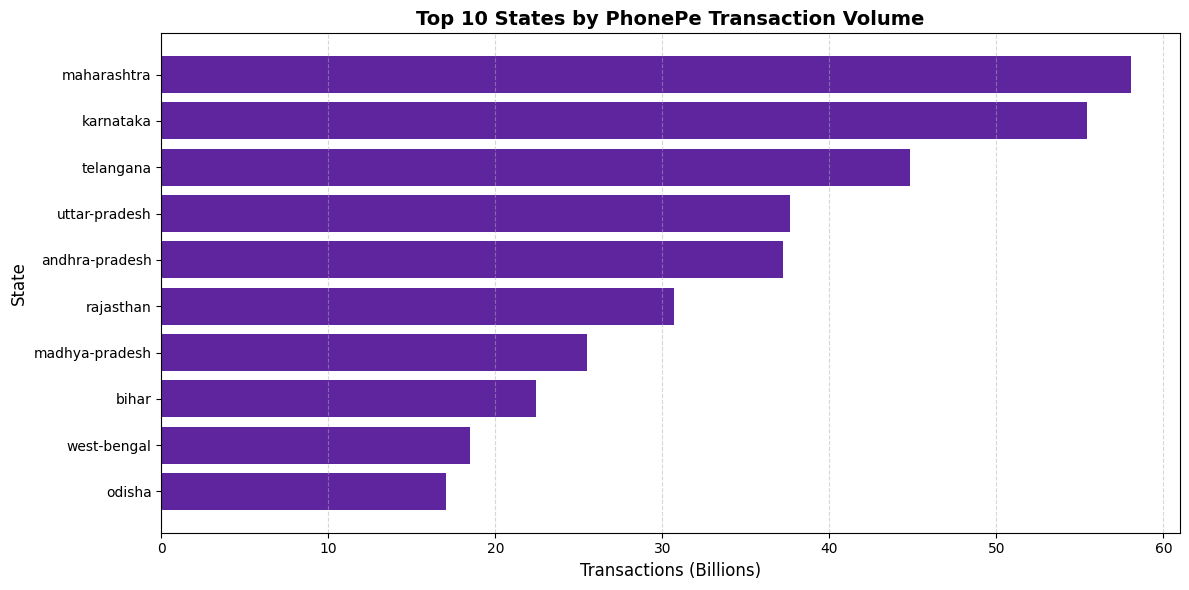

In [26]:
# Visualizing Top 10 States by Transaction Volume
top_10_volume = top_states_volume.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_volume["state"],
    top_10_volume["transactions_bn"],
    color="#5f259f"
)

plt.xlabel("Transactions (Billions)", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.title("Top 10 States by PhonePe Transaction Volume", fontsize=14, fontweight="bold")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [27]:
# Top states by transaction value (₹)
top_states_value = state_summary.sort_values(
    "total_transaction_amount",
    ascending=False
).copy()

top_states_value["amount_trillion"] = (
    top_states_value["total_transaction_amount"] / 1e12
)

top_states_value.head(10)

,state,total_transactions,total_transaction_amount,amount_trillion
15,karnataka,55399289713,6.930963e+13,69.309634
20,maharashtra,58090476182,6.805764e+13,68.057637
31,telangana,44799513185,6.585734e+13,65.857335
1,andhra-pradesh,37210943664,6.193168e+13,61.931675
33,uttar-pradesh,37648808330,4.878129e+13,48.781289
28,rajasthan,30719527575,4.355004e+13,43.550035
4,bihar,22417600473,3.192985e+13,31.929850
19,madhya-pradesh,25481760471,3.175480e+13,31.754795
35,west-bengal,18471647241,2.769694e+13,27.696938
25,odisha,17062129019,2.132037e+13,21.320368


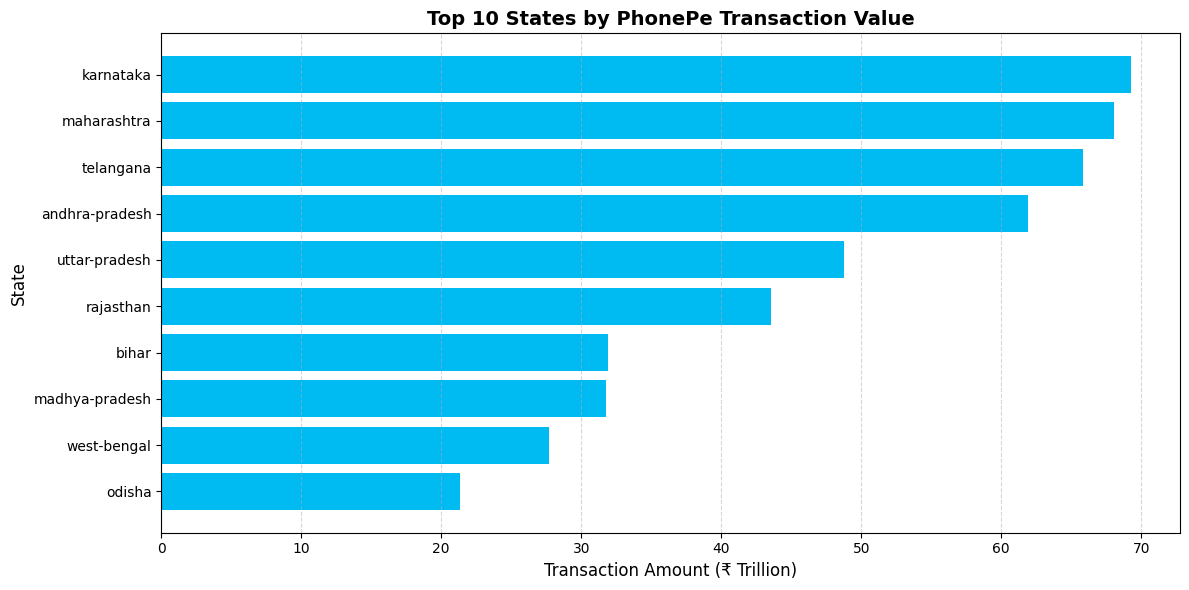

In [28]:
# Visualizing Top 10 States by Transaction Value
top_10_value = top_states_value.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_value["state"],
    top_10_value["amount_trillion"],
    color="#00baf2"
)

plt.xlabel("Transaction Amount (₹ Trillion)", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.title("Top 10 States by PhonePe Transaction Value", fontsize=14, fontweight="bold")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [29]:
# Comparison of Volume vs Value in Top States
comparison = top_states_value[
    ["state", "total_transactions", "total_transaction_amount", "amount_trillion"]
].head(10)

comparison

,state,total_transactions,total_transaction_amount,amount_trillion
15,karnataka,55399289713,6.930963e+13,69.309634
20,maharashtra,58090476182,6.805764e+13,68.057637
31,telangana,44799513185,6.585734e+13,65.857335
1,andhra-pradesh,37210943664,6.193168e+13,61.931675
33,uttar-pradesh,37648808330,4.878129e+13,48.781289
28,rajasthan,30719527575,4.355004e+13,43.550035
4,bihar,22417600473,3.192985e+13,31.929850
19,madhya-pradesh,25481760471,3.175480e+13,31.754795
35,west-bengal,18471647241,2.769694e+13,27.696938
25,odisha,17062129019,2.132037e+13,21.320368


### State-Level Growth Analysis

In [30]:
# State yearly aggregation
state_yearly = (
    df_state.groupby(["state", "year"])
    .agg(
        transactions=("transaction_count", "sum"),
        amount=("transaction_amount", "sum")
    )
    .reset_index()
)

state_yearly = state_yearly.sort_values(["state", "year"])

state_yearly["transaction_growth_pct"] = (
    state_yearly.groupby("state")["transactions"]
    .pct_change() * 100
)

state_yearly.head(10)

,state,year,transactions,amount,transaction_growth_pct
0,andaman-&-nicobar-islands,2018,76444,2.294129e+08,NaN
1,andaman-&-nicobar-islands,2019,169778,6.119765e+08,122.094605
2,andaman-&-nicobar-islands,2020,543783,1.502523e+09,220.290615
3,andaman-&-nicobar-islands,2021,2084411,5.611179e+09,283.316691
4,andaman-&-nicobar-islands,2022,6558177,1.372373e+10,214.629744
5,andaman-&-nicobar-islands,2023,12604291,2.186130e+10,92.191992
6,andaman-&-nicobar-islands,2024,20498243,3.116929e+10,62.629084
7,andaman-&-nicobar-islands,2025,27048708,3.722363e+10,31.956227
8,andaman-&-nicobar-islands,2026,15717596,2.136980e+10,-41.891509
9,andhra-pradesh,2018,90545256,1.385884e+11,NaN


In [31]:
# Example: Yearly trend for Maharashtra
state_yearly[state_yearly["state"] == "maharashtra"]

,state,year,transactions,amount,transaction_growth_pct
180,maharashtra,2018,113979981,1.820916e+11,NaN
181,maharashtra,2019,518444288,7.095140e+11,354.855566
182,maharashtra,2020,1070431504,1.605214e+12,106.469919
183,maharashtra,2021,2577214716,3.744124e+12,140.764094
184,maharashtra,2022,5483814460,7.292825e+12,112.780659
185,maharashtra,2023,8758957523,1.082733e+13,59.723812
186,maharashtra,2024,12808960946,1.479994e+13,46.238418
187,maharashtra,2025,16864743344,1.825195e+13,31.663633
188,maharashtra,2026,9893929420,1.064465e+13,-41.333650


In [32]:
# Top 5 states by volume
top_5_states = top_states_volume.head(5)["state"].tolist()
print("Top 5 States:", top_5_states)

Top 5 States: ['maharashtra', 'karnataka', 'telangana', 'uttar-pradesh', 'andhra-pradesh']


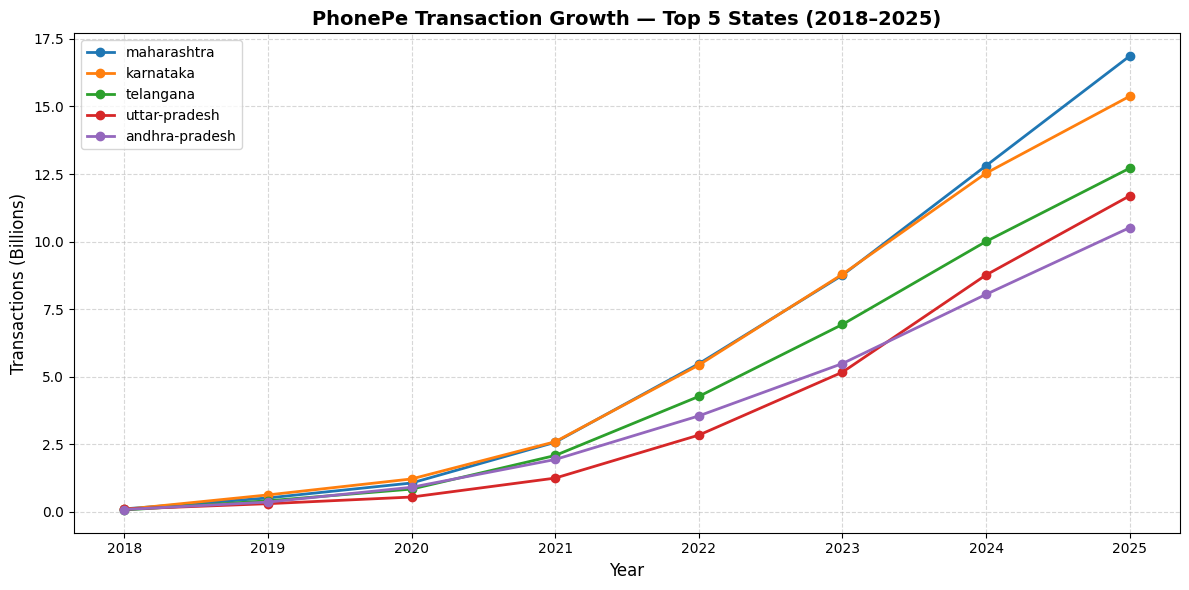

In [33]:
# Yearly trend for Top 5 states (2018-2025 complete years)
top5_yearly = state_yearly[
    (state_yearly["state"].isin(top_5_states)) &
    (state_yearly["year"] < 2026)
]

plt.figure(figsize=(12, 6))

for state in top_5_states:
    data = top5_yearly[top5_yearly["state"] == state]
    plt.plot(
        data["year"],
        data["transactions"] / 1e9,
        marker="o",
        label=state,
        linewidth=2
    )

plt.xlabel("Year", fontsize=12)
plt.ylabel("Transactions (Billions)", fontsize=12)
plt.title("PhonePe Transaction Growth — Top 5 States (2018–2025)", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
# Pivot state transactions (2018 to 2025) and calculate long-term growth %
state_growth = (
    state_yearly[state_yearly["year"].isin([2018, 2025])]
    .pivot(index="state", columns="year", values="transactions")
    .reset_index()
)

state_growth["growth_pct"] = (
    (state_growth[2025] - state_growth[2018])
    / state_growth[2018]
) * 100

state_growth.sort_values("growth_pct", ascending=False).head(10)

year,state,2018,2025,growth_pct
0,andaman-&-nicobar-islands,76444,27048708,35283.690021
17,ladakh,100992,27609635,27238.437698
2,arunachal-pradesh,539973,131996184,24344.960026
31,telangana,71234618,12716111919,17751.028441
3,assam,10315544,1717329553,16547.978555
15,karnataka,93477781,15377209002,16350.121984
22,meghalaya,443653,72584444,16260.634099
20,maharashtra,113979981,16864743344,14696.232809
28,rajasthan,61983307,8898900728,14256.931178
13,jammu-&-kashmir,4288665,612873080,14190.532835


In [35]:
# State quarterly aggregation
state_quarterly = (
    df_state.groupby(["state", "year", "quarter"])
    .agg(
        transactions=("transaction_count", "sum"),
        amount=("transaction_amount", "sum")
    )
    .reset_index()
)

state_quarterly.head(10)

,state,year,quarter,transactions,amount
0,andaman-&-nicobar-islands,2018,1,9089,1.856913e+07
1,andaman-&-nicobar-islands,2018,2,15062,3.551728e+07
2,andaman-&-nicobar-islands,2018,3,21154,6.734342e+07
3,andaman-&-nicobar-islands,2018,4,31139,1.079831e+08
4,andaman-&-nicobar-islands,2019,1,40726,1.263527e+08
5,andaman-&-nicobar-islands,2019,2,46764,1.633548e+08
6,andaman-&-nicobar-islands,2019,3,40623,1.514283e+08
7,andaman-&-nicobar-islands,2019,4,41665,1.708407e+08
8,andaman-&-nicobar-islands,2020,1,49104,1.810273e+08
9,andaman-&-nicobar-islands,2020,2,78685,1.972526e+08


In [36]:
# Maharashtra quarterly records
state_quarterly[
    state_quarterly["state"] == "maharashtra"
].head(10)

,state,year,quarter,transactions,amount
680,maharashtra,2018,1,15771297,2.061628e+10
681,maharashtra,2018,2,21707384,3.456998e+10
682,maharashtra,2018,3,30786153,5.033496e+10
683,maharashtra,2018,4,45715147,7.657040e+10
684,maharashtra,2019,1,73874732,1.075835e+11
685,maharashtra,2019,2,99331337,1.474216e+11
686,maharashtra,2019,3,148759948,1.943523e+11
687,maharashtra,2019,4,196478271,2.601566e+11
688,maharashtra,2020,1,233758463,3.082958e+11
689,maharashtra,2020,2,180429884,2.813546e+11


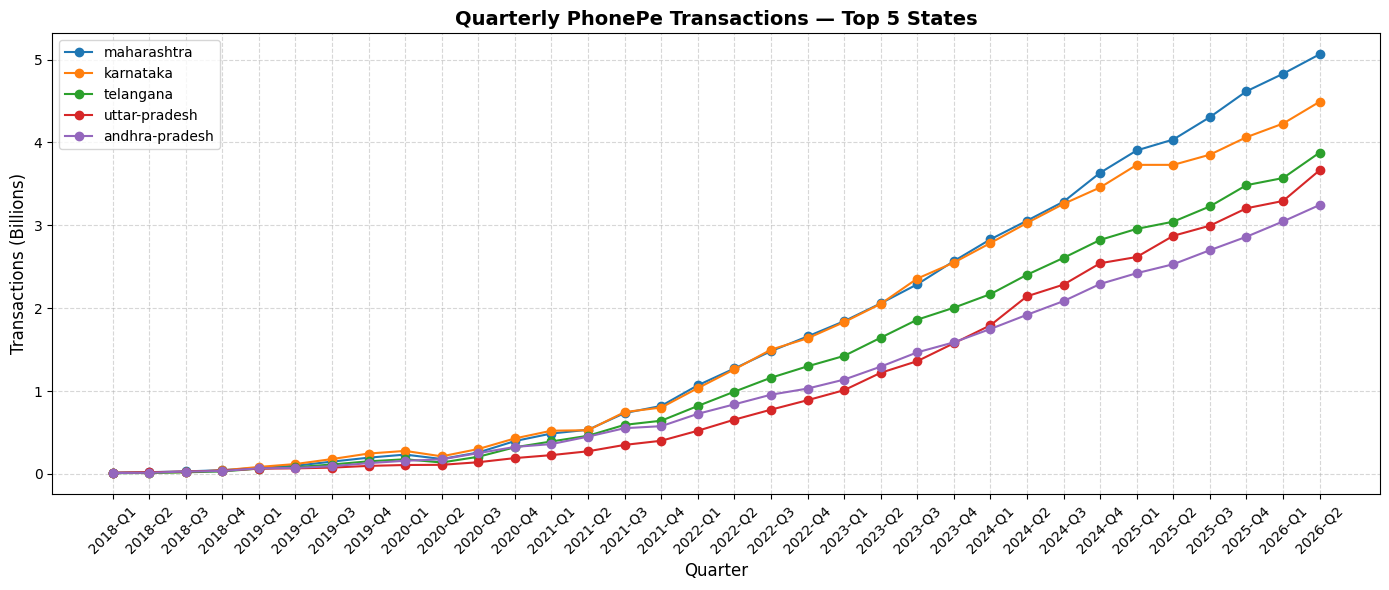

In [37]:
# Top 5 States Quarterly Trend
top5_quarterly = state_quarterly[
    state_quarterly["state"].isin(top_5_states)
].copy()

top5_quarterly["period"] = (
    top5_quarterly["year"].astype(str)
    + "-Q"
    + top5_quarterly["quarter"].astype(str)
)

plt.figure(figsize=(14, 6))

for state in top_5_states:
    data = top5_quarterly[
        top5_quarterly["state"] == state
    ]
    plt.plot(
        data["period"],
        data["transactions"] / 1e9,
        marker="o",
        label=state
    )

plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Transactions (Billions)", fontsize=12)
plt.title("Quarterly PhonePe Transactions — Top 5 States", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Average Transaction Value by State

In [38]:
# Calculate Average Transaction Value (ATV) per State
state_summary["avg_transaction_value"] = (
    state_summary["total_transaction_amount"]
    / state_summary["total_transactions"]
)

avg_value_states = state_summary.sort_values(
    "avg_transaction_value",
    ascending=False
).copy()

avg_value_states["avg_value_rupees"] = (
    avg_value_states["avg_transaction_value"]
)

avg_value_states.head(10)

,state,total_transactions,total_transaction_amount,avg_transaction_value,avg_value_rupees
21,manipur,108948633,2.299302e+11,2110.446159,2110.446159
17,ladakh,88229418,1.746076e+11,1979.018175,1979.018175
24,nagaland,120106382,2.265916e+11,1886.591186,1886.591186
23,mizoram,44575406,8.193987e+10,1838.230582,1838.230582
1,andhra-pradesh,37210943664,6.193168e+13,1664.340352,1664.340352
0,andaman-&-nicobar-islands,85301431,1.333028e+11,1562.726904,1562.726904
27,punjab,3239192497,4.943165e+12,1526.048540,1526.048540
29,sikkim,139727495,2.104581e+11,1506.203836,1506.203836
35,west-bengal,18471647241,2.769694e+13,1499.429775,1499.429775
22,meghalaya,203113422,3.028221e+11,1490.901344,1490.901344


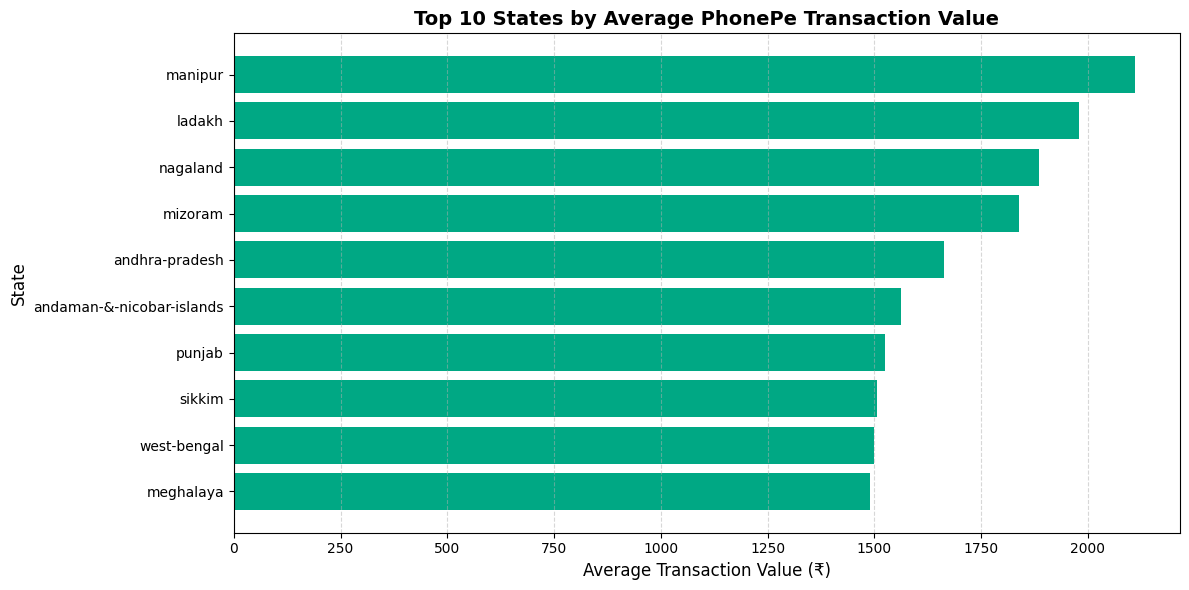

In [39]:
# Visualizing Top 10 States by Average Transaction Value
top10_avg = avg_value_states.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top10_avg["state"],
    top10_avg["avg_value_rupees"],
    color="#00a884"
)

plt.xlabel("Average Transaction Value (₹)", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.title("Top 10 States by Average PhonePe Transaction Value", fontsize=14, fontweight="bold")

plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Key Findings

1. **Exponential Growth**: PhonePe has experienced tremendous growth across both transaction count and transaction amount from 2018 through 2026.
2. **Transaction Types**:
   - **Retail** accounts for the highest transaction count share (~58.7%), reflecting heavy adoption of merchant UPI payments.
   - **P2P (Peer-to-Peer)** accounts for the lion's share of total transaction value (~75.2%), with significantly higher ticket sizes per transaction.
   - **Utility** transactions represent steady baseline bill and recharge usage.
3. **State Dominance**: Maharashtra, Karnataka, Telangana, Andhra Pradesh, and Rajasthan lead across transaction volume and value.
4. **Ticket Size Dynamics**: Certain states and Union Territories have distinct average transaction values, reflecting differing economic and consumer usage patterns.

In [40]:
# Optional: Save aggregated dataset summary to project data folder
output_dir = "../data"
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "phonepe_quarterly_summary.csv")
quarterly_summary.to_csv(output_file, index=False)
print(f"Summary successfully exported to: {output_file}")

Summary successfully exported to: ../data\phonepe_quarterly_summary.csv
